# DANE, ECV Y GEOMETRÍAS — VitalRisk AI

## Encabezado de contexto

Este notebook es parte del proyecto VitalRisk AI (Equipo 326).
Procesa las fuentes territoriales y socioeconómicas que alimentan
la dimensión geográfica del sistema: los 10 municipios del Valle
de Aburrá más el resto de Antioquia.

**Fuentes que procesa:**
- DANE DIVIPOLA: geometrías municipales (GeoJSON IGAC)
- ECV Antioquia 2023: indicadores socioeconómicos invariantes
- DANE Proyecciones CNPV 2018: población anual por municipio

**HUs que cierra:** HU5 + HU6 (fuente territorial)
**Insumo para:** HU7 (cruce con IRA y clima en NB 04)
**Output:** clean_municipios.geojson + clean_poblacion_anual.csv

In [169]:
# %pip install geopandas

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import missingno as msno
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Directorios
RAW_PATH       = Path("../data/raw/")
PROCESSED_PATH = Path("../data/processed/")
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 4. Recolección de Datos

### Fuente 1: Versión MGN2025-Nivel Municipio
Geometrías de los municipios colombianos.

Descarga: https://geoportal.dane.gov.co/servicios/descarga-y-metadatos/datos-geoestadisticos/?cod=111

Formato: ZIP pero vamos a tomar Shapefile. Cargamos con GeoPandas.

### Fuente 2: ECV Antioquia 2023
Indicadores socioeconómicos por municipio.

Archivo: Indicadores_ECV2023.xlsx

Descarga: https://www.antioquiadatos.gov.co/estadisticasAntioquia/encuestaCalidadVida

Nota técnica: el header real está en la fila 15 (skiprows=14).

Formato largo: 1 fila = municipio × indicador × zona.

### Fuente 3: Proyecciones y retroproyecciones de población municipal para el periodo 1985-2017 y 2018-2042 con base en el CNPV 2018 
Población por municipio y año, base CNPV 2018.

Descarga: https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion

###  Geometria

In [3]:
# 1. Cargar el Shapefile directamente desde el ZIP comprimido del DANE
# El parámetro layer(!) especifica qué capa del zip queremos leer
ruta_zip = f"zip://{RAW_PATH / 'DANE/MGN2025_MPIO_GRAFICO.zip'}!MGN_ADM_MPIO_GRAFICO.shp"

print("Cargando geometrías desde el Shapefile comprimido...")
gdf_municipios = gpd.read_file(ruta_zip)

# 2. Filtrar solo los municipios de Antioquia (Código DANE '05')
gdf_antioquia = gdf_municipios[gdf_municipios['dpto_ccdgo'] == '05'].copy()

# 3. Normalizar la columna clave para el JOIN posterior
# Renombramos el código del municipio al estándar de nuestro proyecto
gdf_antioquia = gdf_antioquia.rename(columns={'mpio_cdpmp': 'codigo_dane'})

print(f"Municipios retenidos: {gdf_antioquia.shape[0]}")
print(f"Sistema de coordenadas original: {gdf_antioquia.crs}")

# 4. Transformar al estándar web global (WGS84 - EPSG:4326)
# Esto garantiza que las latitudes y longitudes sean compatibles con Leaflet/Streamlit
gdf_antioquia = gdf_antioquia.to_crs(epsg=4326)

# 5. Exportar el resultado al formato GeoJSON limpio que necesitamos
ruta_salida = PROCESSED_PATH / "clean_municipios_pre.geojson"
gdf_antioquia.to_file(ruta_salida, driver="GeoJSON")

print(f"GeoJSON exportado exitosamente en: {ruta_salida}")
display(gdf_antioquia.head(3))

Cargando geometrías desde el Shapefile comprimido...
Municipios retenidos: 125
Sistema de coordenadas original: EPSG:4326
GeoJSON exportado exitosamente en: ..\data\processed\clean_municipios_pre.geojson


,dpto_ccdgo,mpio_ccdgo,codigo_dane,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.974188,2025,0.810667,0.024253,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548..."


In [172]:
# # 1. Cargar el Shapefile (esta línea ya te está funcionando)
# ruta_zip = f"zip://{RAW_PATH / 'MGN2025_MPIO_GRAFICO.zip'}!MGN_ADM_MPIO_GRAFICO.shp"
# gdf_municipios = gpd.read_file(ruta_zip)

# # 2. Diagnóstico del Schema Drift
# print("Columnas disponibles en el MGN 2025:")
# print(gdf_municipios.columns.tolist())

# # 3. Ver los datos crudos para identificar la columna correcta visualmente
# display(gdf_municipios.head(3))

In [4]:
# ── Fuente 1: Geometrías DIVIPOLA ──────────────────────────
gdf_municipios_test = gpd.read_file(PROCESSED_PATH / "clean_municipios_pre.geojson")

print(f"GeoDataFrame cargado: {gdf_municipios_test.shape}")
print(f"CRS original: {gdf_municipios_test.crs}")
print(f"\nColumnas disponibles: {list(gdf_municipios_test.columns)}")
print(f"\nPrimeras 3 filas:")
display(gdf_municipios_test.head(3))

GeoDataFrame cargado: (125, 12)
CRS original: EPSG:4326

Columnas disponibles: ['dpto_ccdgo', 'mpio_ccdgo', 'codigo_dane', 'dpto_cnmbr', 'mpio_cnmbr', 'mpio_crslc', 'mpio_tipo', 'mpio_narea', 'mpio_nano', 'shape_Leng', 'shape_Area', 'geometry']

Primeras 3 filas:


,dpto_ccdgo,mpio_ccdgo,codigo_dane,dpto_cnmbr,mpio_cnmbr,mpio_crslc,mpio_tipo,mpio_narea,mpio_nano,shape_Leng,shape_Area,geometry
0,05,001,05001,ANTIOQUIA,MEDELLÍN,1965,MUNICIPIO,374.741484,2025,1.035380,0.030608,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05,002,05002,ANTIOQUIA,ABEJORRAL,1814,MUNICIPIO,506.959782,2024,1.158504,0.041384,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05,004,05004,ANTIOQUIA,ABRIAQUÍ,1912,MUNICIPIO,296.974188,2025,0.810667,0.024253,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548..."


### ECV

In [5]:
# ── Fuente 2: ECV Antioquia 2023 ───────────────────────────
# NOTA: header real en fila 15 (skiprows=14)
df_ecv = pd.read_excel(RAW_PATH / "encuesta-calidad-vida-2023/Indicadores_ECV2023.xlsx", skiprows=14)
df_ecv['Codigo'] = df_ecv['Codigo'].astype(str).str.zfill(5)

print(f"ECV cargada: {df_ecv.shape}")
print(f"Columnas: {list(df_ecv.columns)}")
print(f"Indicadores únicos: {df_ecv['NomIndicador'].nunique()}")
print(f"Municipios únicos: {df_ecv['Codigo'].nunique()}")

ECV cargada: (520067, 8)
Columnas: ['Codigo', 'Territorio', 'Clase', 'NomIndicador', 'Valor', 'CV', 'Zona', 'Tipo']
Indicadores únicos: 1122
Municipios únicos: 167


In [5]:
df_ecv.head(10)

,Codigo,Territorio,Clase,NomIndicador,Valor,CV,Zona,Tipo
0,05001,Medellín,Demografía,Tasa de inmigración,4.769617,5.371516,Total,Municipio
1,05001,Medellín,Demografía,Tasa de inmigración de los hombres,4.560909,6.102449,Total,Municipio
2,05001,Medellín,Demografía,Tasa de inmigración de las mujeres,4.954398,5.909871,Total,Municipio
3,05001,Medellín,Demografía,Tasa de inmigración de la población en discapa...,3.332864,17.117592,Total,Municipio
4,05001,Medellín,Demografía,Tasa de inmigración de la población jóven,6.946203,6.550025,Total,Municipio
5,05001,Medellín,Demografía,Tasa de inmigración de la población adulto mayor,1.056916,13.643927,Total,Municipio
6,05001,Medellín,Demografía,Tasa de emigración,1.878414,8.051781,Total,Municipio
7,05001,Medellín,Demografía,Tasa de emigración de los hombres,1.696539,9.692372,Total,Municipio
8,05001,Medellín,Demografía,Tasa de emigración de las mujeres,2.039438,8.697839,Total,Municipio
9,05001,Medellín,Demografía,Tasa de emigración de la población en discapac...,1.030431,24.302947,Total,Municipio


In [6]:
df_ecv.info()

<class 'pandas.DataFrame'>
RangeIndex: 520067 entries, 0 to 520066
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Codigo        520067 non-null  str   
 1   Territorio    520067 non-null  str   
 2   Clase         520067 non-null  str   
 3   NomIndicador  520067 non-null  str   
 4   Valor         506902 non-null  object
 5   CV            404582 non-null  object
 6   Zona          520067 non-null  str   
 7   Tipo          520067 non-null  str   
dtypes: object(2), str(6)
memory usage: 87.5+ MB


In [177]:
# columnasECV = df_ecv['NomIndicador'].value_counts()

In [178]:
# columnasECV.to_csv(PROCESSED_PATH / "indicadores_ecv_frecuencia.csv", index=True, encoding='utf-8')

### Poblacion

In [6]:
# ── Fuente 3: Proyecciones de Población DANE ───────────────
df_pob = pd.read_excel(RAW_PATH / "DANE/PPED-AreaMun-2018-2042_VP.xlsx", skiprows=7, sheet_name="PobMunicipalxÁrea")[1:]

df_pob = df_pob[df_pob['DP']=="05"].copy()  # Filtramos solo Antioquia
df_pob = df_pob[df_pob['ÁREA GEOGRÁFICA']=='Total'].copy()  # Filtramos solo el total del área geográfica

print(f"Proyecciones cargadas: {df_pob.shape}")
print(f"Columnas disponibles: {list(df_pob.columns)}")
display(df_pob.head(3))

Proyecciones cargadas: (3125, 7)
Columnas disponibles: ['DP', 'DPNOM', 'MPIO', 'DPMP', 'AÑO', 'ÁREA GEOGRÁFICA', 'TOTAL']


,DP,DPNOM,MPIO,DPMP,AÑO,ÁREA GEOGRÁFICA,TOTAL
3,05,Antioquia,5001.0,Medellín,2018.0,Total,2427133.0
6,05,Antioquia,5002.0,Abejorral,2018.0,Total,20368.0
9,05,Antioquia,5004.0,Abriaquí,2018.0,Total,2718.0


## 5. Entendimiento de los Datos

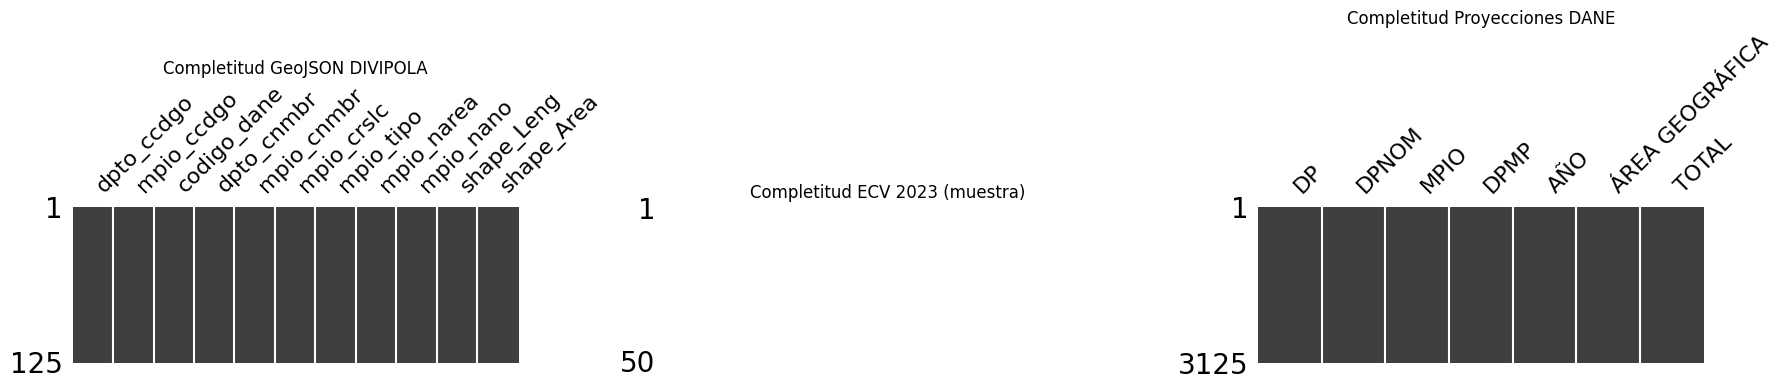

In [7]:
# ── 5.1 Completitud general de las 3 fuentes ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

msno.matrix(gdf_municipios_test.drop(columns=['geometry']), ax=axes[0], sparkline=False)
axes[0].set_title('Completitud GeoJSON DIVIPOLA')

msno.matrix(df_ecv.pivot_table(
    index='Codigo', columns='NomIndicador', values='Valor', aggfunc='first'
).reset_index().head(50), ax=axes[1], sparkline=False)
axes[1].set_title('Completitud ECV 2023 (muestra)')

msno.matrix(df_pob, ax=axes[2], sparkline=False)
axes[2].set_title('Completitud Proyecciones DANE')

plt.tight_layout()
plt.show()

Debido al nivel de granularidad del archivo de la encuesta de calidad de vida, es dificil para el codigo leer los datos y presentaarlos en una matriz de nulidad

In [8]:
# ── 5.2 Análisis del GeoJSON: ¿qué columna tiene el código DANE? ──
print("=== VALORES ÚNICOS EN COLUMNAS CANDIDATAS A CÓDIGO DANE ===")
for col in gdf_municipios.columns:
    sample = gdf_municipios[col].dropna().astype(str).head(3).tolist()
    print(f"  {col:30s}: {sample}")

=== VALORES ÚNICOS EN COLUMNAS CANDIDATAS A CÓDIGO DANE ===
  dpto_ccdgo                    : ['05', '05', '05']
  mpio_ccdgo                    : ['001', '002', '004']
  mpio_cdpmp                    : ['05001', '05002', '05004']
  dpto_cnmbr                    : ['ANTIOQUIA', 'ANTIOQUIA', 'ANTIOQUIA']
  mpio_cnmbr                    : ['MEDELLÍN', 'ABEJORRAL', 'ABRIAQUÍ']
  mpio_crslc                    : ['1965', '1814', '1912']
  mpio_tipo                     : ['MUNICIPIO', 'MUNICIPIO', 'MUNICIPIO']
  mpio_narea                    : ['374.741484489', '506.959782266', '296.974188434']
  mpio_nano                     : ['2025', '2024', '2025']
  shape_Leng                    : ['1.0353795212', '1.15850364793', '0.810666951491']
  shape_Area                    : ['0.0306076494367', '0.0413838961913', '0.0242533145791']
  geometry                      : ['POLYGON ((-75.485696 6.201626, -75.485671 6.201483, -75.485642 6.201417, -75.485607 6.201354, -75.485554 6.201276, -75.485495 6.201

In [9]:
# ── 5.3 Verificar los 10 municipios del Valle de Aburrá ────
VALLE_ABURRA = {
    '05001': 'Medellín',   '05088': 'Bello',
    '05129': 'Caldas',     '05212': 'Copacabana',
    '05266': 'Envigado',   '05308': 'Girardota',
    '05360': 'Itagüí',     '05380': 'La Estrella',
    '05631': 'Sabaneta',   '05837': 'Barbosa'
}

# Ajustar según el nombre real de la columna de código (ver 5.2)
COL_CODIGO = 'codigo_dane' 

print("=== MUNICIPIOS DEL VALLE DE ABURRÁ EN EL GEOJSON ===")
for codigo, nombre in VALLE_ABURRA.items():
    presente = codigo in gdf_municipios_test[COL_CODIGO].values
    print(f"  {'✓' if presente else '✗'} {codigo} — {nombre}")

=== MUNICIPIOS DEL VALLE DE ABURRÁ EN EL GEOJSON ===
  ✓ 05001 — Medellín
  ✓ 05088 — Bello
  ✓ 05129 — Caldas
  ✓ 05212 — Copacabana
  ✓ 05266 — Envigado
  ✓ 05308 — Girardota
  ✓ 05360 — Itagüí
  ✓ 05380 — La Estrella
  ✓ 05631 — Sabaneta
  ✓ 05837 — Barbosa


#### Entendimiento de los datos de ECV

- **El Indicador de Calidad de Vida - ICV:** en Antioquia es una medida estadística integral y multidimensional utilizada para evaluar el bienestar socioeconómico, las condiciones de vida y el desarrollo de los hogares en el departamento
- **Hacinamiento:** densidad poblacional por residencia
- **Proporcion de menores de 6 años:** Que porcentaje de las personas en la vivienda son menores de 6 años
- **Seguridad social:** Nivel de seguridad social que tiene el denominado proveedor del hogar
- **Porcentaje NBI:** indicador socioeconómico que mide la proporción de la población que carece de las condiciones estructurales mínimas de bienestar. A diferencia de la pobreza monetaria, el NBI evalúa carencias en calidad de vida
- **Porcentaje de vivienda con SP acueducto:** indicador que mide la proporción de hogares que tienen acceso a agua potable mediante una conexión formal a la red pública.
- **Porcentaje de IPM:** representa la proporción de la población que no solo sufre carencias de ingresos, sino que experimenta múltiples privaciones simultáneas en áreas básicas como la educación, la salud, el trabajo, la niñez y las condiciones de la vivienda
- **Material paredes:** variable que clasifica el material principal de construcción de las paredes exteriores de la vivienda.
- **Material pisos:** Material predominante de los pisos de la vivienda

In [10]:
# ── 5.4 Análisis ECV: verificar los indicadores que necesitamos ──
INDICADORES_TARGET = {
    'Indicador de calidad de vida - ICV':           'icv_score',
    'D4 V1 Hacinamiento':                            'icv_hacinamiento',
    'D4 V2 Proporción de menores de 6 años':         'icv_menores_6',
    'D5 V2 Seguridad social jefe del hogar':         'icv_seg_social',
    'Porcentaje de personas en condición de pobreza por NBI': 'nbi',
    'Porcentaje de viviendas con SP Acueducto':      'pct_vivienda_acueducto',
    'Porcentaje de personas pobres - IPM':           'ipm_pct',
    'D1 V1 Material paredes': 						  'icv_paredes',
    'D1 V2 Material pisos': 						  'icv_pisos',
}

print("=== DISPONIBILIDAD DE INDICADORES REQUERIDOS EN ECV ===")
indicadores_disponibles = df_ecv['NomIndicador'].unique()
for ind_ecv, col_modelo in INDICADORES_TARGET.items():
    # Búsqueda flexible (contiene)
    matches = [i for i in indicadores_disponibles if ind_ecv.lower() in i.lower()]
    if matches:
        print(f"  ✓ '{col_modelo}' → encontrado como: '{matches[0]}'")
    else:
        print(f"  ✗ '{col_modelo}' → NO encontrado. Buscar alternativa.")

=== DISPONIBILIDAD DE INDICADORES REQUERIDOS EN ECV ===
  ✓ 'icv_score' → encontrado como: 'Indicador de calidad de vida - ICV'
  ✓ 'icv_hacinamiento' → encontrado como: 'D4 V1 Hacinamiento'
  ✓ 'icv_menores_6' → encontrado como: 'D4 V2 Proporción de menores de 6 años'
  ✓ 'icv_seg_social' → encontrado como: 'D5 V2 Seguridad social jefe del hogar'
  ✓ 'nbi' → encontrado como: 'Porcentaje de personas en condición de pobreza por NBI'
  ✓ 'pct_vivienda_acueducto' → encontrado como: 'Porcentaje de viviendas con SP Acueducto'
  ✓ 'ipm_pct' → encontrado como: 'Porcentaje de personas pobres - IPM'
  ✓ 'icv_paredes' → encontrado como: 'D1 V1 Material paredes'
  ✓ 'icv_pisos' → encontrado como: 'D1 V2 Material pisos'


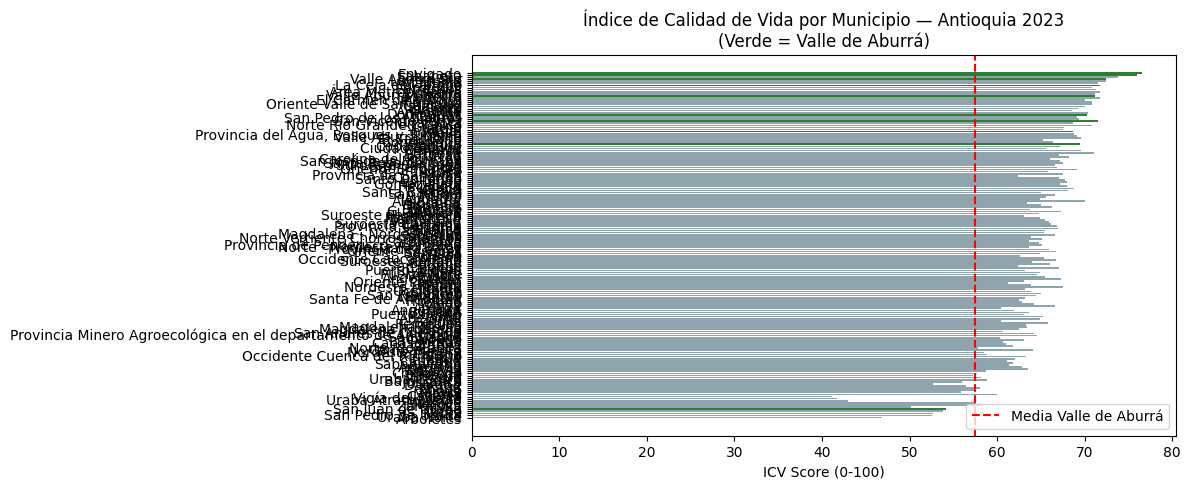


Estadísticas ICV Antioquia: count     332.000000
unique    328.000000
top        45.939566
freq        2.000000
Name: Valor, dtype: float64


In [11]:
# ── 5.5 Distribución del ICV en municipios de Antioquia ────
df_icv = df_ecv[
    (df_ecv['NomIndicador'].str.contains('Indicador de calidad de vida', case=False)) &
    (df_ecv['Zona'] == 'Total')
].copy()

plt.figure(figsize=(12, 5))
df_icv_sorted = df_icv.sort_values('Valor')
plt.barh(df_icv_sorted['Territorio'], df_icv_sorted['Valor'],
         color=['#2E7D32' if c in VALLE_ABURRA else '#90A4AE'
                for c in df_icv_sorted['Codigo']])
plt.axvline(x=df_icv_sorted[df_icv_sorted['Codigo'].isin(VALLE_ABURRA)]['Valor'].mean(),
            color='red', linestyle='--', label='Media Valle de Aburrá')
plt.xlabel('ICV Score (0-100)')
plt.title('Índice de Calidad de Vida por Municipio — Antioquia 2023\n(Verde = Valle de Aburrá)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nEstadísticas ICV Antioquia: {df_icv['Valor'].describe()}")

In [12]:
# ── 5.6 Análisis Proyecciones de Población ─────────────────
print("=== PROYECCIONES DE POBLACIÓN — COBERTURA TEMPORAL ===")
# Ajustar según las columnas reales del archivo DANE
print(df_pob.describe())

# print(f"\nAños disponibles: {sorted(df_pob.columns.tolist())}")
df_pob['codigo_dane'] = df_pob['MPIO'].astype(float).astype(int).astype(str).str.zfill(5)

# Verificar que los 10 municipios del Valle de Aburrá están cubiertos
for codigo, nombre in VALLE_ABURRA.items():
    # Ajustar según nombre real de la columna de código en el archivo DANE
    presente = codigo in df_pob['codigo_dane'].astype(str).values
    print(f"  {'✓' if presente else '✗'} {codigo} — {nombre}")

=== PROYECCIONES DE POBLACIÓN — COBERTURA TEMPORAL ===
              MPIO          AÑO         TOTAL
count  3125.000000  3125.000000  3.125000e+03
mean   5415.744000  2030.000000  5.589000e+04
std     279.771717     7.212257  2.283335e+05
min    5001.000000  2018.000000  2.558000e+03
25%    5147.000000  2024.000000  9.134000e+03
50%    5376.000000  2030.000000  1.757200e+04
75%    5659.000000  2036.000000  3.302100e+04
max    5895.000000  2042.000000  2.528343e+06
  ✓ 05001 — Medellín
  ✓ 05088 — Bello
  ✓ 05129 — Caldas
  ✓ 05212 — Copacabana
  ✓ 05266 — Envigado
  ✓ 05308 — Girardota
  ✓ 05360 — Itagüí
  ✓ 05380 — La Estrella
  ✓ 05631 — Sabaneta
  ✓ 05837 — Barbosa


## 6. Preparación de los Datos

### 6.1 Limpieza y estandarización del GeoJSON
### 6.2 Extracción y pivoteo de indicadores ECV
### 6.3 Cruce GeoJSON + ECV → dim_municipios
### 6.4 Preparación de proyecciones de población → dim_poblacion_anual
### 6.5 Validación final y exportación

In [13]:
# ── 6.1 Limpieza del GeoJSON ───────────────────────────────
# Ajustar COL_CODIGO al nombre real encontrado en 5.2

gdf_clean = gdf_municipios_test[[COL_CODIGO, 'mpio_cnmbr', 'dpto_cnmbr', 'geometry']].copy()
gdf_clean = gdf_clean.rename(columns={
    COL_CODIGO:    'codigo_dane',
    'mpio_cnmbr':  'nombre',
    'DPTO_CNMBR':  'departamento',
})

# Asegurar código DANE de 5 dígitos
gdf_clean['codigo_dane'] = gdf_clean['codigo_dane'].astype(str).str.zfill(5)

# Reproyectar a WGS84 (SRID 4326) — requerido por PostGIS
if gdf_clean.crs.to_epsg() != 4326:
    gdf_clean = gdf_clean.to_crs(epsg=4326)
    print(f"CRS reproyectado a WGS84 (EPSG:4326)")

# Filtrar solo Antioquia (código departa 05)
gdf_antioquia = gdf_clean[gdf_clean['codigo_dane'].str.startswith('05')].copy()

print(f"Municipios de Antioquia en el GeoJSON: {len(gdf_antioquia)}")
print(f"CRS final: {gdf_antioquia.crs}")
gdf_antioquia.head(3)

Municipios de Antioquia en el GeoJSON: 125
CRS final: EPSG:4326


,codigo_dane,nombre,dpto_cnmbr,geometry
0,05001,MEDELLÍN,ANTIOQUIA,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,..."
1,05002,ABEJORRAL,ANTIOQUIA,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571..."
2,05004,ABRIAQUÍ,ANTIOQUIA,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548..."


In [14]:
# ── 6.2 Extracción de indicadores ECV (pivoteo de largo a ancho) ──
# Buscamos palabras clave relacionadas con humo interior y humedad estructural
palabras_clave = 'leña|cocinar|combustible|piso|pared|tierra|contaminación'
candidatos = df_ecv[df_ecv['NomIndicador'].str.contains(palabras_clave, case=False, na=False)]

print("Posibles variables para mejorar el modelo:")
for ind in candidatos['NomIndicador'].unique():
    print(f"- {ind}")

Posibles variables para mejorar el modelo:
- Número de viviendas en déficit por Material de las paredes exteriores - Cuantitativo
- Porcentaje de viviendas en déficit por Material de las paredes exteriores - Cuantitativo
- Número de viviendas en déficit por Material de los pisos - Cualitativo
- Número de viviendas en déficit por Material de los pisos - Cualitativo Jerarquizado
- Porcentaje de viviendas en déficit por Material de los pisos - Cualitativo
- Porcentaje de viviendas en déficit por Material de los pisos - Cualitativo Jerarquizado
- Porcentaje de personas privadas por pisos inadecuados
- Porcentaje de hombres privadas por pisos inadecuados
- Porcentaje de mujeres privadas por pisos inadecuados
- Porcentaje de hogares privadas por pisos inadecuados
- Porcentaje de personas privadas por paredes inadecuadas
- Porcentaje de hombres privadas por paredes inadecuadas
- Porcentaje de mujeres privadas por paredes inadecuadas
- Porcentaje de hogares privadas por paredes inadecuadas
- D

In [15]:
# 1. Filtramos la ECV para evitar duplicar sumando áreas urbanas y rurales
df_ecv_total = df_ecv[df_ecv['Zona'] == 'Total'].copy()
# crea un dataframe copiando solo los códigos DANE únicos para luego hacer un merge con los indicadores que vamos a extraer
df_ecv_wide = pd.DataFrame({'codigo_dane': df_ecv_total['Codigo'].unique()})

#Ya teniamos unos indicadores que nos interesaban, ahora sumamos los indicadores que encontramos en el paso anterior y que podrían mejorar el modelo. relacionando el estado de las viviendas con la vulnerabilidad estructural y la exposición a humo interior.

# 2. Diccionario de mapeo: conecta el nombre exacto del Excel con la columna del init.sql
mapa_indicadores = {
    # ── Macro-índices de Pobreza (Se evaluará colinealidad en el EDA) ──
    'Indicador de calidad de vida - ICV': 'icv_score',
    'Porcentaje de personas en condición de pobreza por NBI': 'nbi',
    'Porcentaje de personas pobres - IPM': 'ipm_pct',
    
    # ── Vectores de Transmisión (Densidad) ──
    'D4 V1 Hacinamiento': 'icv_hacinamiento',
    
    # ── Vulnerabilidad Inmunológica (Demografía) ──
    'D4 V2 Proporción de menores de 6 años': 'icv_menores_6',
    
    # ── Capacidad de Respuesta (Acceso a salud e higiene) ──
    'D5 V2 Seguridad social jefe del hogar': 'icv_seg_social',
    'Porcentaje de viviendas con SP Acueducto': 'pct_vivienda_acueducto',
    
    # ── Vulnerabilidad Estructural (Humedad y micro-partículas) ──
    'D1 V1 Material paredes': 'icv_paredes',
    'D1 V2 Material pisos': 'icv_pisos',
    
}

for indicador_ecv, col_nombre in mapa_indicadores.items():
    # Buscar el indicador (flexible: contiene el texto)
    mask = (
        df_ecv['NomIndicador'].str.contains(indicador_ecv, case=False, na=False) &
        (df_ecv['Zona'] == 'Total')
    )
    # 4. Extraemos solo las columnas relevantes y hacemos una copia para evitar SettingWithCopyWarning asociado al elemento del diccionario
    df_temp = df_ecv[mask][['Codigo', 'Valor', 'CV']].copy()
    # 5. Renombramos para cruzar (Codigo -> codigo_dane) y estandarizamos columnas
    df_temp = df_temp.rename(columns={
        'Codigo': 'codigo_dane',
        'Valor':  col_nombre,
        'CV':     f'{col_nombre}_cv'
    })
    # 6. Pivotear a formato ancho (wide) para cada indicador
    df_ecv_wide = df_ecv_wide.merge(df_temp, on='codigo_dane', how='left')
    
# Advertir sobre CV alto (baja confiabilidad estadística)
cv_cols = [c for c in df_ecv_wide.columns if c.endswith('_cv')]
for col in cv_cols:
    high_cv = (df_ecv_wide[col] > 15).sum()
    if high_cv > 0:
        print(f"⚠ {col}: {high_cv} municipios con CV > 15% (baja confiabilidad)")

⚠ nbi_cv: 102 municipios con CV > 15% (baja confiabilidad)
⚠ ipm_pct_cv: 109 municipios con CV > 15% (baja confiabilidad)
⚠ pct_vivienda_acueducto_cv: 1 municipios con CV > 15% (baja confiabilidad)


In [21]:
print(df_ecv_wide[df_ecv_wide['nbi_cv'] > 15]['codigo_dane'].tolist())

['05002', '05004', '05021', '05030', '05034', '05036', '05038', '05042', '05044', '05045', '05055', '05059', '05079', '05086', '05091', '05093', '05101', '05113', '05120', '05125', '05129', '05138', '05142', '05145', '05147', '05148', '05150', '05154', '05172', '05190', '05197', '05206', '05209', '05212', '05234', '05237', '05240', '05264', '05266', '05282', '05284', '05306', '05308', '05310', '05313', '05315', '05318', '05321', '05347', '05360', '05361', '05364', '05368', '05376', '05380', '05400', '05411', '05440', '05467', '05480', '05483', '05490', '05501', '05541', '05543', '05576', '05579', '05585', '05591', '05604', '05607', '05615', '05628', '05631', '05642', '05649', '05652', '05656', '05658', '05660', '05664', '05667', '05670', '05674', '05679', '05686', '05690', '05697', '05761', '05789', '05792', '05809', '05819', '05847', '05854', '05856', '05858', '05861', '05885', '05887', '05890', '05893']


In [22]:
print(df_ecv_wide[df_ecv_wide['ipm_pct_cv'] > 15]['codigo_dane'].tolist())

['05002', '05004', '05021', '05030', '05031', '05034', '05036', '05040', '05042', '05044', '05045', '05055', '05059', '05079', '05086', '05091', '05101', '05113', '05125', '05129', '05138', '05142', '05145', '05147', '05148', '05150', '05154', '05172', '05190', '05197', '05206', '05212', '05237', '05240', '05264', '05266', '05282', '05284', '05306', '05308', '05310', '05313', '05315', '05318', '05321', '05347', '05353', '05360', '05361', '05364', '05368', '05376', '05380', '05390', '05400', '05411', '05440', '05467', '05475', '05480', '05483', '05490', '05501', '05541', '05543', '05576', '05579', '05585', '05591', '05604', '05607', '05615', '05628', '05631', '05642', '05649', '05652', '05656', '05658', '05660', '05664', '05665', '05667', '05670', '05674', '05679', '05686', '05690', '05697', '05736', '05761', '05789', '05792', '05809', '05819', '05837', '05842', '05847', '05854', '05856', '05858', '05861', '05873', '05885', '05887', '05890', '00Z08', '00Z12', '00Z03']


In [23]:
print(df_ecv_wide[df_ecv_wide['pct_vivienda_acueducto_cv'] > 15]['codigo_dane'].tolist()) #Este elemento posee un CV estable o preciso en nbi pero no en imp_pct

['05475']


In [24]:
print(f"ECV Pivotada: {df_ecv_wide.shape}")

display(df_ecv_wide.head(5))

ECV Pivotada: (167, 19)


,codigo_dane,icv_score,icv_score_cv,nbi,nbi_cv,ipm_pct,ipm_pct_cv,icv_hacinamiento,icv_hacinamiento_cv,icv_menores_6,icv_menores_6_cv,icv_seg_social,icv_seg_social_cv,pct_vivienda_acueducto,pct_vivienda_acueducto_cv,icv_paredes,icv_paredes_cv,icv_pisos,icv_pisos_cv
0,05001,71.139971,0.110115,6.408513,5.237003,6.036842,5.966357,2.248531,0.465444,1.747716,0.424203,3.01482,0.376967,98.668546,0.131433,7.42816,0.210816,8.130799,0.219391
1,05002,65.238596,1.077824,19.420227,19.475556,13.520753,24.863147,2.764644,4.034074,2.261524,3.287764,2.613362,3.343711,94.332725,2.00718,6.892455,2.673816,7.051244,3.311319
2,05004,65.613322,1.095394,9.298882,28.849242,9.103361,34.867156,3.023376,3.209967,2.278688,3.254795,2.629269,3.415042,87.013608,3.160084,7.631821,2.165249,7.06747,2.832188
3,05021,64.938706,0.817827,10.562205,33.761014,11.785118,27.191491,2.810179,3.587179,2.0721,2.984997,2.574532,3.542342,88.563638,2.388244,7.269813,1.660729,6.882411,2.192984
4,05030,66.613521,0.763902,13.127143,20.904375,12.039421,21.765291,2.900386,2.909873,2.132897,2.708052,2.92817,2.705443,97.755074,1.022433,6.737119,1.630248,7.515594,1.996577


In [16]:
# marcar los valores con baja confiabilidad
# pero NO eliminarlos — los mantenemos con una bandera

columna_confiabilidad = df_ecv_wide.copy()

for ind_ecv, col_nombre in mapa_indicadores.items():
    cv_col = f'{col_nombre}_cv'
    if cv_col in columna_confiabilidad.columns:
        # Crear columna de confiabilidad: True = dato confiable (CV <= 15%)
        columna_confiabilidad[f'{col_nombre}_confiable'] = columna_confiabilidad[cv_col] <= 15

# Reporte para los 10 municipios del Valle de Aburrá
va_mask = columna_confiabilidad['codigo_dane'].isin(VALLE_ABURRA.keys())
print("\n=== CONFIABILIDAD EN VALLE DE ABURRÁ ===")
cols_conf = [c for c in columna_confiabilidad.columns if c.endswith('_confiable')]
val_apoyo = columna_confiabilidad[va_mask][['codigo_dane'] + cols_conf].to_string()
print(val_apoyo)


=== CONFIABILIDAD EN VALLE DE ABURRÁ ===
    codigo_dane  icv_score_confiable  nbi_confiable  ipm_pct_confiable  icv_hacinamiento_confiable  icv_menores_6_confiable  icv_seg_social_confiable  pct_vivienda_acueducto_confiable  icv_paredes_confiable  icv_pisos_confiable
0         05001                 True           True               True                        True                     True                      True                              True                   True                 True
18        05088                 True           True               True                        True                     True                      True                              True                   True                 True
26        05129                 True          False              False                        True                     True                      True                              True                   True                 True
40        05212                 True          

In [17]:
df_ecv_wide = df_ecv_wide[df_ecv_wide['codigo_dane'].str.match(r'^\d{5}$')]
df_ecv_wide = df_ecv_wide[df_ecv_wide['codigo_dane'] != '00005']
# Solo conservar códigos que son exactamente 5 dígitos numéricos
print(f"Filas eliminadas con código inválido: {167 - len(df_ecv_wide)}")

Filas eliminadas con código inválido: 42


In [18]:
print(f"ECV Pivotada: {df_ecv_wide.shape}")

df_ecv_wide

ECV Pivotada: (125, 19)


,codigo_dane,icv_score,icv_score_cv,nbi,nbi_cv,ipm_pct,ipm_pct_cv,icv_hacinamiento,icv_hacinamiento_cv,icv_menores_6,icv_menores_6_cv,icv_seg_social,icv_seg_social_cv,pct_vivienda_acueducto,pct_vivienda_acueducto_cv,icv_paredes,icv_paredes_cv,icv_pisos,icv_pisos_cv
0,05001,71.139971,0.110115,6.408513,5.237003,6.036842,5.966357,2.248531,0.465444,1.747716,0.424203,3.01482,0.376967,98.668546,0.131433,7.42816,0.210816,8.130799,0.219391
1,05002,65.238596,1.077824,19.420227,19.475556,13.520753,24.863147,2.764644,4.034074,2.261524,3.287764,2.613362,3.343711,94.332725,2.00718,6.892455,2.673816,7.051244,3.311319
2,05004,65.613322,1.095394,9.298882,28.849242,9.103361,34.867156,3.023376,3.209967,2.278688,3.254795,2.629269,3.415042,87.013608,3.160084,7.631821,2.165249,7.06747,2.832188
3,05021,64.938706,0.817827,10.562205,33.761014,11.785118,27.191491,2.810179,3.587179,2.0721,2.984997,2.574532,3.542342,88.563638,2.388244,7.269813,1.660729,6.882411,2.192984
4,05030,66.613521,0.763902,13.127143,20.904375,12.039421,21.765291,2.900386,2.909873,2.132897,2.708052,2.92817,2.705443,97.755074,1.022433,6.737119,1.630248,7.515594,1.996577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,05885,64.91348,1.005539,11.261643,24.810098,19.05404,20.36509,2.731335,3.345838,2.17313,2.969525,2.42838,2.480162,96.008852,1.528303,7.276697,2.19732,6.549517,2.423756
121,05887,67.555426,0.645385,12.190773,17.74715,11.47993,18.881583,2.440148,2.307488,1.864121,2.195462,2.532793,2.099181,93.045187,1.133268,7.37521,1.223707,7.939027,1.306311
122,05890,63.893689,1.022858,23.997342,22.094512,16.7949,26.177441,2.945909,3.563038,2.460186,2.658749,2.644302,3.552711,86.055267,3.585338,7.793413,2.341353,6.770461,2.247126
123,05893,58.05322,0.987944,15.971569,16.384238,20.414546,14.811295,2.505426,3.24496,1.853089,3.418692,2.419155,2.566444,89.240804,2.228549,5.07088,4.025998,5.434926,2.72977


In [19]:
df_ecv_wide.columns

Index(['codigo_dane', 'icv_score', 'icv_score_cv', 'nbi', 'nbi_cv', 'ipm_pct',
       'ipm_pct_cv', 'icv_hacinamiento', 'icv_hacinamiento_cv',
       'icv_menores_6', 'icv_menores_6_cv', 'icv_seg_social',
       'icv_seg_social_cv', 'pct_vivienda_acueducto',
       'pct_vivienda_acueducto_cv', 'icv_paredes', 'icv_paredes_cv',
       'icv_pisos', 'icv_pisos_cv'],
      dtype='str')

In [20]:
df_ecv_wide.info()

<class 'pandas.DataFrame'>
Index: 125 entries, 0 to 124
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   codigo_dane                125 non-null    str   
 1   icv_score                  125 non-null    object
 2   icv_score_cv               125 non-null    object
 3   nbi                        125 non-null    object
 4   nbi_cv                     125 non-null    object
 5   ipm_pct                    125 non-null    object
 6   ipm_pct_cv                 125 non-null    object
 7   icv_hacinamiento           125 non-null    object
 8   icv_hacinamiento_cv        125 non-null    object
 9   icv_menores_6              125 non-null    object
 10  icv_menores_6_cv           125 non-null    object
 11  icv_seg_social             125 non-null    object
 12  icv_seg_social_cv          125 non-null    object
 13  pct_vivienda_acueducto     125 non-null    object
 14  pct_vivienda_acueducto_cv 

In [21]:
df_ecv_wide.columns

Index(['codigo_dane', 'icv_score', 'icv_score_cv', 'nbi', 'nbi_cv', 'ipm_pct',
       'ipm_pct_cv', 'icv_hacinamiento', 'icv_hacinamiento_cv',
       'icv_menores_6', 'icv_menores_6_cv', 'icv_seg_social',
       'icv_seg_social_cv', 'pct_vivienda_acueducto',
       'pct_vivienda_acueducto_cv', 'icv_paredes', 'icv_paredes_cv',
       'icv_pisos', 'icv_pisos_cv'],
      dtype='str')

In [22]:
cols_numericas = ['icv_score', 'icv_score_cv', 'nbi', 'nbi_cv', 'ipm_pct',
       'ipm_pct_cv', 'icv_hacinamiento', 'icv_hacinamiento_cv',
       'icv_menores_6', 'icv_menores_6_cv', 'icv_seg_social',
       'icv_seg_social_cv', 'pct_vivienda_acueducto',
       'pct_vivienda_acueducto_cv', 'icv_paredes', 'icv_paredes_cv',
       'icv_pisos', 'icv_pisos_cv']
for col in cols_numericas:
    df_ecv_wide[col] = pd.to_numeric(df_ecv_wide[col], errors='coerce')
    
df_ecv_wide.info()

<class 'pandas.DataFrame'>
Index: 125 entries, 0 to 124
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   codigo_dane                125 non-null    str    
 1   icv_score                  125 non-null    float64
 2   icv_score_cv               125 non-null    float64
 3   nbi                        125 non-null    float64
 4   nbi_cv                     125 non-null    float64
 5   ipm_pct                    125 non-null    float64
 6   ipm_pct_cv                 125 non-null    float64
 7   icv_hacinamiento           125 non-null    float64
 8   icv_hacinamiento_cv        125 non-null    float64
 9   icv_menores_6              125 non-null    float64
 10  icv_menores_6_cv           125 non-null    float64
 11  icv_seg_social             125 non-null    float64
 12  icv_seg_social_cv          125 non-null    float64
 13  pct_vivienda_acueducto     125 non-null    float64
 14  pct_vivien

Municipios con datos ECV:             125/125
Valle de Aburrá con datos ECV:         10/10
Municipios sin datos ECV (NaN):        0


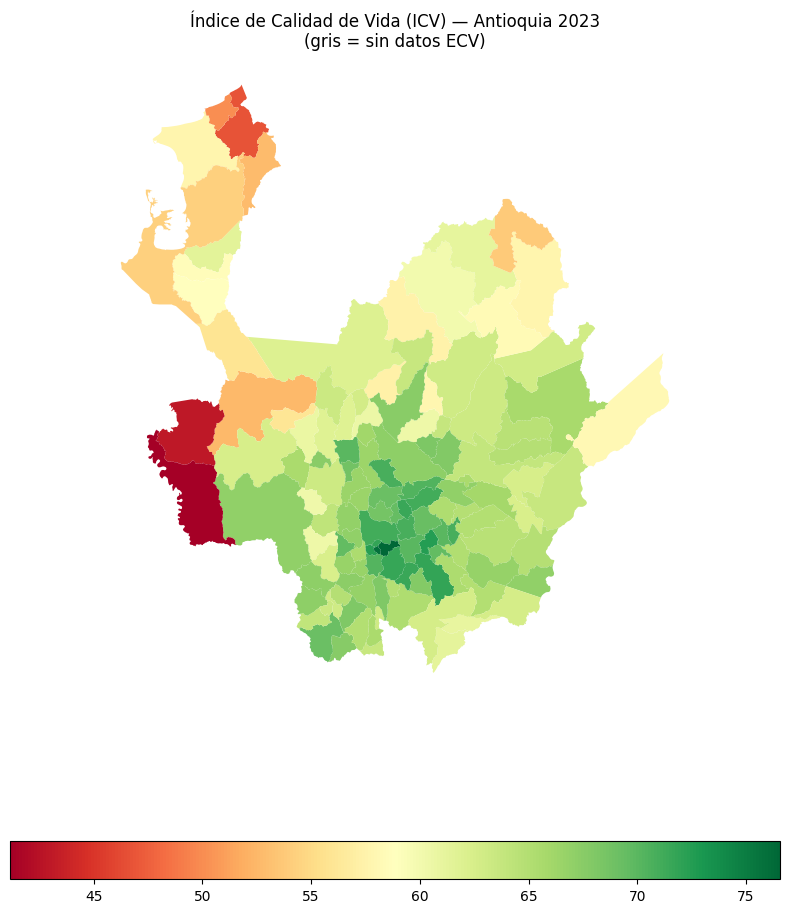

In [23]:
# ── 6.3 Cruce GeoJSON + ECV ────────────────────────────────
gdf_municipios_final = gdf_antioquia.merge(
    df_ecv_wide.drop(columns=cv_cols),  # quitar columnas CV del merge final
    on='codigo_dane',
    how='left'
)

# Agregar subregión del Valle de Aburrá
gdf_municipios_final['subregion'] = gdf_municipios_final['codigo_dane'].map(
    {k: 'Valle de Aburrá' for k in VALLE_ABURRA}
).fillna('Resto de Antioquia')

# Diagnóstico del cruce
n_con_ecv = gdf_municipios_final['icv_score'].notna().sum()
n_total = len(gdf_municipios_final)
n_va_con_ecv = gdf_municipios_final[
    gdf_municipios_final['subregion'] == 'Valle de Aburrá'
]['icv_score'].notna().sum()

# Aseguramos que la variable de color sea numérica para que GeoPandas use una escala continua
gdf_municipios_final['icv_score'] = pd.to_numeric(gdf_municipios_final['icv_score'], errors='coerce')

print(f"Municipios con datos ECV:             {n_con_ecv}/{n_total}")
print(f"Valle de Aburrá con datos ECV:         {n_va_con_ecv}/10")
print(f"Municipios sin datos ECV (NaN):        {n_total - n_con_ecv}")

# Mapa de cobertura
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_municipios_final.plot(
    column='icv_score',
    ax=ax,
    legend=True,
    cmap='RdYlGn',
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos ECV'},
    legend_kwds={'orientation': 'horizontal'}
)
ax.set_title('Índice de Calidad de Vida (ICV) — Antioquia 2023\n(gris = sin datos ECV)',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

In [24]:
gdf_municipios_final.head(10)

,codigo_dane,nombre,dpto_cnmbr,geometry,icv_score,nbi,ipm_pct,icv_hacinamiento,icv_menores_6,icv_seg_social,pct_vivienda_acueducto,icv_paredes,icv_pisos,subregion
0,05001,MEDELLÍN,ANTIOQUIA,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,...",71.139971,6.408513,6.036842,2.248531,1.747716,3.014820,98.668546,7.428160,8.130799,Valle de Aburrá
1,05002,ABEJORRAL,ANTIOQUIA,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571...",65.238596,19.420227,13.520753,2.764644,2.261524,2.613362,94.332725,6.892455,7.051244,Resto de Antioquia
2,05004,ABRIAQUÍ,ANTIOQUIA,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548...",65.613322,9.298882,9.103361,3.023376,2.278688,2.629269,87.013608,7.631821,7.067470,Resto de Antioquia
3,05021,ALEJANDRÍA,ANTIOQUIA,"POLYGON ((-75.0332 6.41586, -75.03313 6.41585,...",64.938706,10.562205,11.785118,2.810179,2.072100,2.574532,88.563638,7.269813,6.882411,Resto de Antioquia
4,05030,AMAGÁ,ANTIOQUIA,"POLYGON ((-75.67587 6.08561, -75.6754 6.08491,...",66.613521,13.127143,12.039421,2.900386,2.132897,2.928170,97.755074,6.737119,7.515594,Resto de Antioquia
5,05031,AMALFI,ANTIOQUIA,"POLYGON ((-74.91364 7.28807, -74.91361 7.28789...",63.211458,24.965703,18.838385,2.589464,2.006762,2.387022,72.607460,6.971151,6.534777,Resto de Antioquia
6,05034,ANDES,ANTIOQUIA,"POLYGON ((-75.86822 5.75753, -75.86827 5.75673...",69.110835,12.943040,18.974331,2.944892,2.227304,2.590675,95.115323,8.295445,7.620409,Resto de Antioquia
7,05036,ANGELÓPOLIS,ANTIOQUIA,"POLYGON ((-75.69149 6.1932, -75.6908 6.19319, ...",65.474912,15.773279,17.052256,2.842392,2.230180,2.956889,96.936045,6.787396,7.235149,Resto de Antioquia
8,05038,ANGOSTURA,ANTIOQUIA,"POLYGON ((-75.27173 6.97094, -75.27164 6.9709,...",60.440189,21.635340,28.418991,3.034022,2.407449,2.567074,86.672642,7.357201,6.406453,Resto de Antioquia
9,05040,ANORÍ,ANTIOQUIA,"POLYGON ((-74.90935 7.45001, -74.9091 7.45001,...",63.077160,30.979847,19.136406,2.573647,2.109540,2.311339,77.718701,7.495930,6.812956,Resto de Antioquia


In [25]:
# ── 6.4 Proyecciones de población → dim_poblacion_anual ────

# La columna MPIO ya tiene el código completo. Solo garantizamos el formato string de 5 caracteres.
# Forzamos a float para absorber decimales, luego a int para quitar el .0, 
# luego a string y finalmente rellenamos con ceros.
df_pob = df_pob[df_pob['AÑO'] < 2024].copy()  # Filtramos solo los años 2023 en adelante
df_pob['codigo_dane'] = df_pob['MPIO'].astype(float).astype(int).astype(str).str.zfill(5)
# Opcional pero recomendado: arreglar también el año para que no sea float
df_pob['AÑO'] = df_pob['AÑO'].astype(int)# Renombramos las columnas para que coincidan exactamente con la base de datos PostGIS
df_pob = df_pob.rename(columns={'AÑO': 'anio', 'TOTAL': 'poblacion_total'})

display(df_pob.head(3))

,DP,DPNOM,MPIO,DPMP,anio,ÁREA GEOGRÁFICA,poblacion_total,codigo_dane
3,05,Antioquia,5001.0,Medellín,2018,Total,2427133.0,05001
6,05,Antioquia,5002.0,Abejorral,2018,Total,20368.0,05002
9,05,Antioquia,5004.0,Abriaquí,2018,Total,2718.0,05004


In [26]:
df_pob.info()

<class 'pandas.DataFrame'>
Index: 750 entries, 3 to 17220
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DP               750 non-null    str    
 1   DPNOM            750 non-null    str    
 2   MPIO             750 non-null    float64
 3   DPMP             750 non-null    str    
 4   anio             750 non-null    int64  
 5   ÁREA GEOGRÁFICA  750 non-null    str    
 6   poblacion_total  750 non-null    float64
 7   codigo_dane      750 non-null    str    
dtypes: float64(2), int64(1), str(5)
memory usage: 75.2 KB


In [31]:
df_pob.head()

,DP,DPNOM,MPIO,DPMP,anio,ÁREA GEOGRÁFICA,poblacion_total,codigo_dane
3,05,Antioquia,5001.0,Medellín,2018,Total,2427133.0,05001
6,05,Antioquia,5002.0,Abejorral,2018,Total,20368.0,05002
9,05,Antioquia,5004.0,Abriaquí,2018,Total,2718.0,05004
12,05,Antioquia,5021.0,Alejandría,2018,Total,4642.0,05021
15,05,Antioquia,5030.0,Amagá,2018,Total,30230.0,05030


In [34]:
# Seleccionamos solo las columnas requeridas por el modelo de datos
df_poblacion_final = df_pob[['codigo_dane', 'anio', 'poblacion_total']].copy()

df_poblacion_final['codigo_dane'] = (
    df_poblacion_final['codigo_dane']
    .astype(str)
    .str.zfill(5)
)

# Exportamos el CSV limpio
ruta_pob = PROCESSED_PATH / "clean_poblacion_anual.csv"
df_poblacion_final.to_csv(ruta_pob, index=False)
print(f"Dimensión Población exportada: {df_poblacion_final.shape}")

Dimensión Población exportada: (750, 3)


In [ ]:
# Verificar INMEDIATAMENTE leyendo el CSV que se acaba de escribir
df_verificacion = pd.read_csv(ruta_pob, dtype={'codigo_dane': str})
print(f"Dimensión exportada: {df_poblacion_final.shape}")
print(f"Muestra de codigo_dane en el CSV leído: {df_verificacion['codigo_dane'].head(5).tolist()}")
print(f"Largo mínimo del código: {df_verificacion['codigo_dane'].str.len().min()} (debe ser 5)")
# df = pd.read_csv(ruta_pob, dtype={'codigo_dane': str})

Dimensión exportada: (750, 3)
Muestra de codigo_dane en el CSV leído: ['05001', '05002', '05004', '05021', '05030']
Largo mínimo del código: 5 (debe ser 5)


In [28]:
# Extraemos únicamente la población del año más reciente (2023) para la tabla maestra
pob_2023 = df_poblacion_final[df_poblacion_final['anio'] == 2023][['codigo_dane', 'poblacion_total']]
pob_2023 = pob_2023.rename(columns={'poblacion_total': 'poblacion_2023'})

# # Merge 1: Geometrías + ECV Socioeconómica (Left join para no perder polígonos si falta un dato)
# gdf_final = gdf_municipios.merge(df_ecv_wide, on='codigo_dane', how='left')

# Merge 2: Resultado + Población 2023
gdf_final = gdf_municipios_final.merge(pob_2023, on='codigo_dane', how='left')

# Validamos que los municipios del Valle de Aburrá (ej. Medellín 05001) tengan datos
display(gdf_final[gdf_final['codigo_dane'] == '05001'])

# Exportamos el GeoJSON final
# ruta_geo = PROCESSED_PATH / "clean_municipios.geojson"
# gdf_final.to_file(ruta_geo, driver="GeoJSON")
print(f"Dimensión Municipios exportada: {gdf_final.shape}")

,codigo_dane,nombre,dpto_cnmbr,geometry,icv_score,nbi,ipm_pct,icv_hacinamiento,icv_menores_6,icv_seg_social,pct_vivienda_acueducto,icv_paredes,icv_pisos,subregion,poblacion_2023
0,05001,MEDELLÍN,ANTIOQUIA,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,...",71.139971,6.408513,6.036842,2.248531,1.747716,3.01482,98.668546,7.42816,8.130799,Valle de Aburrá,2518480.0


Dimensión Municipios exportada: (125, 15)


In [29]:
gdf_final.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   codigo_dane             125 non-null    str     
 1   nombre                  125 non-null    str     
 2   dpto_cnmbr              125 non-null    str     
 3   geometry                125 non-null    geometry
 4   icv_score               125 non-null    float64 
 5   nbi                     125 non-null    float64 
 6   ipm_pct                 125 non-null    float64 
 7   icv_hacinamiento        125 non-null    float64 
 8   icv_menores_6           125 non-null    float64 
 9   icv_seg_social          125 non-null    float64 
 10  pct_vivienda_acueducto  125 non-null    float64 
 11  icv_paredes             125 non-null    float64 
 12  icv_pisos               125 non-null    float64 
 13  subregion               125 non-null    str     
 14  poblacion_2023    

In [30]:
# ── 6.5 Validación final ───────────────────────────────────
print("=== VALIDACIÓN FINAL ANTES DE EXPORTAR ===\n")

# dim_municipios
print("── dim_municipios (GeoJSON final) ──")
print(f"  Filas: {len(gdf_final)}")
print(f"  Columnas: {list(gdf_final.columns)}")
print(f" Numero de Columnas: {len(gdf_final.columns)}")
print(f"  CRS: {gdf_final.crs}")
print(f"  Nulos en codigo_dane: {gdf_final['codigo_dane'].isna().sum()}")
print(f"  Nulos en icv_score (Valle Aburrá):")
va = gdf_final[gdf_final['subregion'] == 'Valle de Aburrá']
print(f"    {va['icv_score'].isna().sum()} / 10 municipios sin ICV")

# dim_poblacion_anual
print("\n── dim_poblacion_anual ──")
print(f"  Filas: {len(df_poblacion_final)}")
print(f"  Años cubiertos: {sorted(df_poblacion_final['anio'].unique())}")
print(f"  Nulos en poblacion_total: {df_poblacion_final['poblacion_total'].isna().sum()}")

# Verificar que codigo_dane de población existe en GeoJSON
codigos_pob  = set(df_poblacion_final['codigo_dane'])
codigos_geo  = set(gdf_final['codigo_dane'])
sin_geometria = codigos_pob - codigos_geo
if sin_geometria:
    print(f"\n⚠ {len(sin_geometria)} municipios en población SIN geometría: {list(sin_geometria)[:5]}")
else:
    print("\n✓ Todos los municipios de población tienen geometría")

=== VALIDACIÓN FINAL ANTES DE EXPORTAR ===

── dim_municipios (GeoJSON final) ──
  Filas: 125
  Columnas: ['codigo_dane', 'nombre', 'dpto_cnmbr', 'geometry', 'icv_score', 'nbi', 'ipm_pct', 'icv_hacinamiento', 'icv_menores_6', 'icv_seg_social', 'pct_vivienda_acueducto', 'icv_paredes', 'icv_pisos', 'subregion', 'poblacion_2023']
 Numero de Columnas: 15
  CRS: EPSG:4326
  Nulos en codigo_dane: 0
  Nulos en icv_score (Valle Aburrá):
    0 / 10 municipios sin ICV

── dim_poblacion_anual ──
  Filas: 750
  Años cubiertos: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Nulos en poblacion_total: 0

✓ Todos los municipios de población tienen geometría


In [36]:
gdf_final.head(3)

,codigo_dane,nombre,dpto_cnmbr,geometry,icv_score,nbi,ipm_pct,icv_hacinamiento,icv_menores_6,icv_seg_social,pct_vivienda_acueducto,icv_paredes,icv_pisos,subregion,poblacion_2023
0,05001,MEDELLÍN,ANTIOQUIA,"POLYGON ((-75.4857 6.20163, -75.48567 6.20148,...",71.139971,6.408513,6.036842,2.248531,1.747716,3.014820,98.668546,7.428160,8.130799,Valle de Aburrá,2518480.0
1,05002,ABEJORRAL,ANTIOQUIA,"POLYGON ((-75.46938 5.94575, -75.46897 5.94571...",65.238596,19.420227,13.520753,2.764644,2.261524,2.613362,94.332725,6.892455,7.051244,Resto de Antioquia,21030.0
2,05004,ABRIAQUÍ,ANTIOQUIA,"POLYGON ((-76.09047 6.74542, -76.09066 6.74548...",65.613322,9.298882,9.103361,3.023376,2.278688,2.629269,87.013608,7.631821,7.067470,Resto de Antioquia,2782.0


In [38]:
gdf_final = gdf_final.rename(columns={'dpto_cnmbr': 'departamento'})
gdf_final.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   codigo_dane             125 non-null    str     
 1   nombre                  125 non-null    str     
 2   departamento            125 non-null    str     
 3   geometry                125 non-null    geometry
 4   icv_score               125 non-null    float64 
 5   nbi                     125 non-null    float64 
 6   ipm_pct                 125 non-null    float64 
 7   icv_hacinamiento        125 non-null    float64 
 8   icv_menores_6           125 non-null    float64 
 9   icv_seg_social          125 non-null    float64 
 10  pct_vivienda_acueducto  125 non-null    float64 
 11  icv_paredes             125 non-null    float64 
 12  icv_pisos               125 non-null    float64 
 13  subregion               125 non-null    str     
 14  poblacion_2023    

In [39]:
# 5. Exportación final
# Exportar de nuevo el GeoJSON (ahora pesará mucho menos)
gdf_final.to_file(PROCESSED_PATH / "clean_municipios.geojson", driver="GeoJSON")